In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA

### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [3]:
# Fetch dataset
energy_efficiency = fetch_ucirepo(id=242)

# Convert to dataframe
feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [4]:
# Separate predictors (X) from response (y)
X = df[feature_names]
y = df['Heating Load']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit scaler only on train data
scaler = StandardScaler().fit(X_train)

# Scale data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [6]:
# Fit OLS regression on training data 
ols = LinearRegression().fit(X_train, y_train)

# Make predictions
y_pred = ols.predict(X_test)

# Calculate MSE 
mse_ols = mean_squared_error(y_test, y_pred)

# Print MSE and inspect coefficients
print(f"OLS Test MSE: {mse_ols:.4f}")

# Table to inspect coefficients from OLS 
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': ols.coef_
}) 

print(coef_df.to_string(index=False))

OLS Test MSE: 8.8402
                  Feature  OLS Coefficient
     Relative Compactness    -6.386753e+01
             Surface Area    -8.736463e+09
                Wall Area     8.736463e+09
                Roof Area     1.747293e+10
           Overall Height     4.125574e+00
              Orientation    -2.357210e-02
             Glazing Area     1.992667e+01
Glazing Area Distribution     2.307234e-01


In [7]:
grader.check("q2")

q2 results: All test cases passed!

In [8]:
# Changing to scaled OLS regression for remainder of task
# want to scale for comparison with Lasso and Ridge coefficients and plotting

# Fit OLS regression on training data 
ols_scaled = LinearRegression().fit(X_train_scaled, y_train)

# Make predictions
y_pred_scaled = ols_scaled.predict(X_test_scaled)

# Calculate MSE 
mse_ols_scaled = mean_squared_error(y_test, y_pred_scaled)

# Print MSE and inspect coefficients
print(f"OLS Test MSE: {mse_ols_scaled:.4f}")

# Table to inspect coefficients from OLS 
coef_df_scaled = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': ols_scaled.coef_
}) 

print(coef_df_scaled.to_string(index=False))

OLS Test MSE: 8.8801
                  Feature  OLS Coefficient
     Relative Compactness    -6.686924e+00
             Surface Area    -2.898797e+13
                Wall Area     1.440817e+13
                Roof Area     2.962227e+13
           Overall Height     7.222607e+00
              Orientation    -3.705020e-02
             Glazing Area     2.901476e+00
Glazing Area Distribution     8.389402e-02


### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [9]:
# Create array of lambda values search over
lambdas = np.logspace(-4, 4, 100)

# Fit ridge regression for each lambda using 10-fold CV
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')

# Fit training data
ridge_cv.fit(X_train_scaled, y_train)

# Lambda with best CV score
print(f"Best Ridge lambda: {ridge_cv.alpha_:.6f}")

# Table to compare coefficients from OLS and Ridge
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': ols.coef_,
    'Ridge Coefficient': ridge_cv.coef_
})

print(coef_df.to_string(index=False))

Best Ridge lambda: 0.205651
                  Feature  OLS Coefficient  Ridge Coefficient
     Relative Compactness    -6.386753e+01          -6.352418
             Surface Area    -8.736463e+09          -3.474392
                Wall Area     8.736463e+09           0.816587
                Roof Area     1.747293e+10          -3.797180
           Overall Height     4.125574e+00           7.306373
              Orientation    -2.357210e-02          -0.025299
             Glazing Area     1.992667e+01           2.670852
Glazing Area Distribution     2.307234e-01           0.356417


In [10]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**

The penalty term correctly served to shrink the coefficients with similarly large magnitudes, Surface area, Wall area, and Roof area, closer to zero. As Ridge coefficients, they can only grow if accompanied by a large enough reduction in the residual sum of squares.

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [11]:
# Predict on test set
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)

# Compute MSE
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)

# Print Test MSE
print(f"Ridge Test MSE: {mse_rcv:.4f}")

Ridge Test MSE: 8.8440


In [12]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

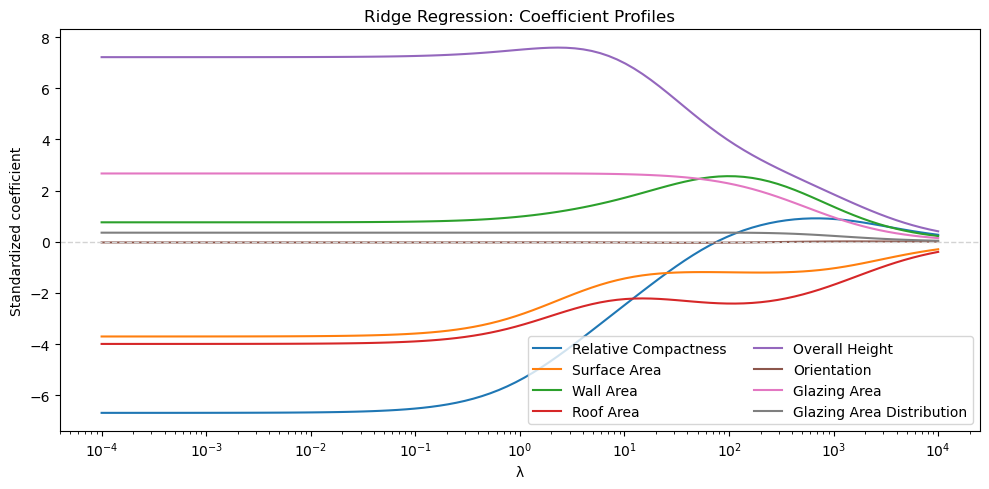

In [13]:
# Visualize Coefficient values acorss Ridge model lambdas 
coefs = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)

    ridge.fit(X_train_scaled, y_train)

    # Store coefficients
    coefs.append(ridge.coef_)

coefs = np.array(coefs)
    
# Plot Ridge Coefficient path
plt.figure(figsize=(10, 5))
for i, feature in enumerate(feature_names):
    plt.plot(lambdas, coefs[:, i], label=feature)
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Standardized coefficient')
plt.title('Ridge Regression: Coefficient Profiles')
plt.legend(loc='lower right', ncols=2)
plt.axhline(0, color='lightgrey', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

`Overall Height` and `Relative Compactness` appear to be the most important in the coefficient profile because they have the largest magnitudes at low values of lambda in the Ridge regression, so they are likely the most important predictors of `Heating Load`.

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [14]:
# Fit LassoCV model using lambda range and 10-fold CV
lasso_cv = LassoCV(alphas=lambdas, cv=10, max_iter=10000) # got convergence warnings and added this...

# Fit training data
lasso_cv.fit(X_train_scaled, y_train)

# Lambda with best CV score
print(f"Best Lasso lambda: {lasso_cv.alpha_:.6f}")

# Table to compare coefficients from OLS and Lasso
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': ols.coef_,
    'Lasso Coefficient': lasso_cv.coef_
})

print(coef_df.to_string(index=False))

Best Lasso lambda: 0.001630
                  Feature  OLS Coefficient  Lasso Coefficient
     Relative Compactness    -6.386753e+01          -6.418330
             Surface Area    -8.736463e+09          -6.231035
                Wall Area     8.736463e+09           2.152524
                Roof Area     1.747293e+10          -1.044324
           Overall Height     4.125574e+00           7.309160
              Orientation    -2.357210e-02          -0.023593
             Glazing Area     1.992667e+01           2.670194
Glazing Area Distribution     2.307234e-01           0.354971


In [15]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

Lasso and Ridge shrank the coefficients that were not initially large in magnitude to similar values. However, Lasso and Ridge varied on how they dealt with `Surface Area`, `Wall Area`, and `Roof Area`. `Surface Area` and `Wall Area` coefficients ended up closer to 0 in Ridge while `Roof Area` ended up closer to 0 in Lasso. This might be related to how the penalty term works in each, where Lasso uses the absolute value and can shrink the coefficients to zero (although did not within this range of lambdas) and Ridge uses their squares and cannot.

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [16]:
# Predict on test set
y_test_pred_lcv = lasso_cv.predict(X_test_scaled)

# Compute MSE
mse_lcv = mean_squared_error(y_test, y_test_pred_lcv)

In [17]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [18]:
# Table to compare Test MSE for OLS, Ridge CV, and Lasso CV
mse_df = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'Test MSE': [mse_ols, mse_rcv, mse_lcv]
})

print(mse_df.to_string(index=False))

Model  Test MSE
  OLS  8.840180
Ridge  8.843961
Lasso  8.841571


The test MSE for all three models were very similar, but OLS had the lowest at 8.840.

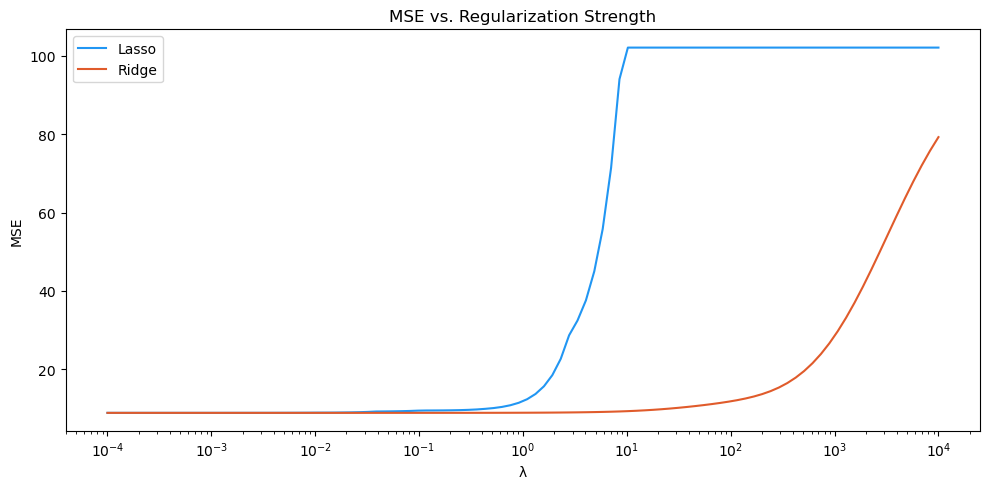

In [19]:
# Visualize lambdas against MSE for Lasso and Ridge
mse_lasso = []
mse_ridge = []

lambdas = np.logspace(-4, 4, 100)

for lam in lambdas:
    lasso = Lasso(alpha=lam, max_iter=10000)# added for warnings
    ridge = Ridge(alpha=lam)

    lasso.fit(X_train_scaled, y_train)
    ridge.fit(X_train_scaled, y_train)

    # Evaluate on test set
    mse_lasso.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
    mse_ridge.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))
    

plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_lasso, label='Lasso', color='#2196F3')
plt.plot(lambdas, mse_ridge, label='Ridge', color='#E05B2B')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.title('MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()

Lasso is more sensitive to regularization strength or changes in the lambda parameter, causing MSE to spike earlier than Ridge at about 0. 

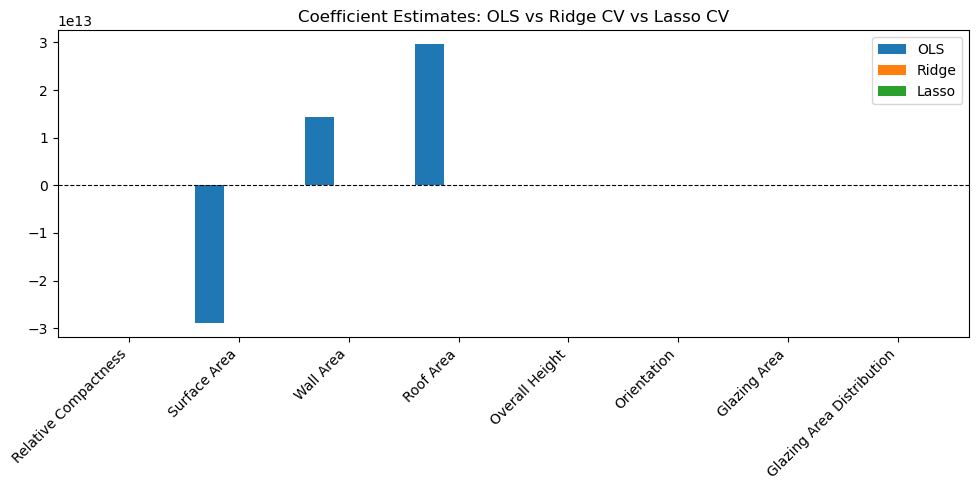

In [20]:
# Visualize coefficient estimates for OLS, Ridge, and Lasso
coef_df = pd.DataFrame({
    'OLS': ols_scaled.coef_,
    'Ridge': ridge_cv.coef_,
    'Lasso': lasso_cv.coef_
}, index=feature_names)

ax = coef_df.plot.bar(figsize = (10,5), width=0.8)
ax.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--')
ax.set_xticklabels(feature_names, rotation = 45, ha = 'right')
ax.set_title('Coefficient Estimates: OLS vs Ridge CV vs Lasso CV')
plt.tight_layout()
plt.show()

As lambda increases, the coefficient estimates shrink more. Lasso coefficient estimates shrink entirely to 0 at a certain threshold.

> **Q4: Which model would you pick for this dataset? Why?**

I would pick Ridge regression, because it seems to handle the possible correlations between surface area, wall area, and roof area (the large coefficients in OLS) in a more stable way without reducing them completely to 0 and removing them from the model. They might be important, as shown in the plot of coefficient profiles where surface area and roof area had similarly high importance at low lambda values. Near the optimal value of lambda for Ridge (0.2), the most important predictors remain in the final figure. The test MSEs between OLS, Ridge, and Lasso are within .004 of one another, so it seems reasonable to select ridge despite it not having the actual lowest test MSE. 

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

In [21]:
# PCA object using all components
pca = PCA(n_components=8)

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [22]:
# Fit on scaled training data
pca_full = pca.fit(X_train_scaled)

# Store array of variance explained by each PC
explained_var = pca.explained_variance_ratio_

# Cumulative variance total
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

explained_var

array([4.62904753e-01, 1.56318178e-01, 1.49748425e-01, 1.24314772e-01,
       9.96632239e-02, 6.47726840e-03, 5.73378958e-04, 2.73013007e-32])

In [23]:
# Create table of each component's individual and cumulative explained variance
var_df = pd.DataFrame({
    'Component': ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'],
    'Individual explained variance': (explained_var * 100),
    'Cumulative explained variance': (cumulative_var * 100)
})

print(var_df.to_string(index=False))

Component  Individual explained variance  Cumulative explained variance
      PC1                   4.629048e+01                      46.290475
      PC2                   1.563182e+01                      61.922293
      PC3                   1.497484e+01                      76.897136
      PC4                   1.243148e+01                      89.328613
      PC5                   9.966322e+00                      99.294935
      PC6                   6.477268e-01                      99.942662
      PC7                   5.733790e-02                     100.000000
      PC8                   2.730130e-30                     100.000000


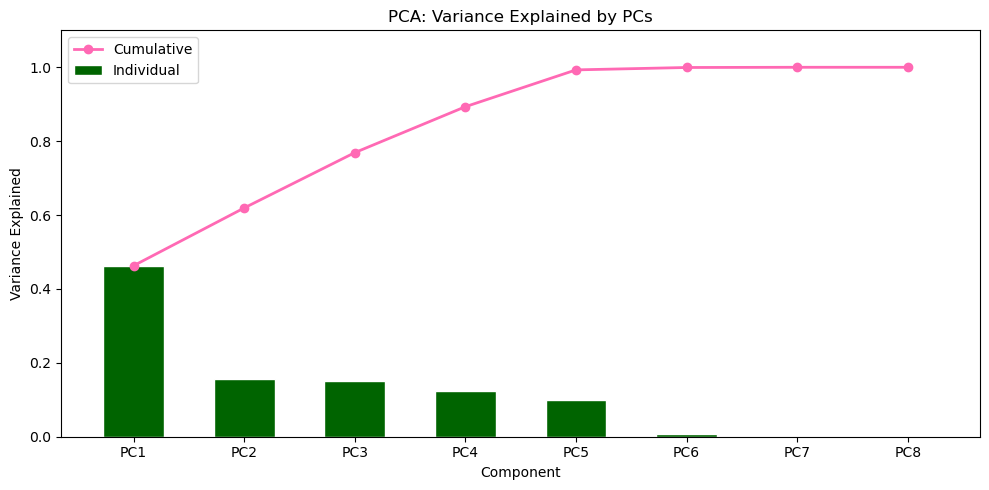

In [42]:
# Bar plot showing individual explained variance for each component, line plot overlayed with cumulative variance
components = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8']

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_ylabel('Variance Explained')
ax.set_xlabel('Component')
ax.set_title('PCA: Variance Explained by PCs')

ax.plot(components, cumulative_var, color='hotpink', marker='o', linewidth=2, label='Cumulative')
ax.bar(components, explained_var, color='darkgreen', edgecolor='white', width=0.55, label='Individual')
ax.set_ylim(0, 1.1)
ax.legend()

plt.tight_layout()
plt.show()

In [25]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

5 principal components explain 99.295% of the variance in the features, as seen in the plot where the elbow is located above PC5 and adding any additional PCs does not increase the cumulative variance explained substanitally enough to be included.

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [43]:
# Set k based on the elbow / ~90% cumulative variance threshold in the plot above
best_k = 5

pca_final = PCA(n_components=best_k).fit(X_train_scaled)
X_train_pca = pca_final.transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

ols_pcr = LinearRegression().fit(X_train_pca, y_train)

y_pred_pcr = ols_pcr.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)



<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

5, because 5 components explain most of the variance.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

In [44]:
# Summary table
summary_df = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso', 'PCR'],
    'Tuning Parameter': ['N/A', ridge_cv.alpha_, lasso_cv.alpha_, best_k],
    'Test MSE': [mse_ols, mse_rcv, mse_lcv, mse_pcr]
})

print(summary_df.to_string(index=False))

Model Tuning Parameter  Test MSE
  OLS              N/A  8.840180
Ridge         0.205651  8.843961
Lasso          0.00163  8.841571
  PCR                5 12.703310


For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

OLS has the lowest test MSE.

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [27]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!